In [41]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [2]:
# Connect to database
conn = sqlite3.connect('rossmann.db')
cursor = conn.cursor()

# Print table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('rossmann',)]


In [3]:
# Assign 'rossmann' table to Pandas DataFramed.isn
sql = "SELECT * FROM rossmann"
df = pd.read_sql(sql, conn)

### Data Fields  
*(Source: [Kaggle — Rossmann Store Sales Competition](https://www.kaggle.com/competitions/rossmann-store-sales/data))*

- **Id** — Identifier representing a `(Store, Date)` pair within the test set.  
- **Store** — Unique identifier for each store.  
- **Sales** — Turnover for a given day (*target variable to predict*).  
- **Customers** — Number of customers on a given day.  
- **Open** — Store open indicator: `0 = Closed`, `1 = Open`.  
- **StateHoliday** — Indicates a state holiday:  
  `a = Public holiday`, `b = Easter holiday`, `c = Christmas`, `0 = None`.  
  Normally stores are closed on state holidays (with some exceptions).  
  *Note: Schools are also closed on public holidays and weekends.*  
- **SchoolHoliday** — Indicates whether the `(Store, Date)` was affected by the closure of public schools.  
- **StoreType** — Differentiates between four store models: `a`, `b`, `c`, `d`.  
- **Assortment** — Describes the product assortment level: `a = Basic`, `b = Extra`, `c = Extended`.  
- **CompetitionDistance** — Distance (in meters) to the nearest competitor store.  
- **CompetitionOpenSince[Month/Year]** — Approximate month and year when the nearest competitor opened.  
- **Promo** — Indicates whether a store ran a promotion on that day (`0 = No`, `1 = Yes`).  
- **Promo2** — Indicates participation in a continuous promotional campaign: `0 = Not participating`, `1 = Participating`.  
- **Promo2Since[Year/Week]** — Year and calendar week when the store began participating in Promo2.  
- **PromoInterval** — Lists the months in which Promo2 restarts, e.g. `"Feb,May,Aug,Nov"` means the promotion renews in February, May, August and November each year.  


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 19 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   index                      1017209 non-null  int64  
 1   Store                      1017209 non-null  int64  
 2   DayOfWeek                  1017209 non-null  int64  
 3   Date                       1017209 non-null  object 
 4   Sales                      1017209 non-null  int64  
 5   Customers                  1017209 non-null  int64  
 6   Open                       1017209 non-null  int64  
 7   Promo                      1017209 non-null  int64  
 8   StateHoliday               1017209 non-null  object 
 9   SchoolHoliday              1017209 non-null  int64  
 10  StoreType                  1017209 non-null  object 
 11  Assortment                 1017209 non-null  object 
 12  CompetitionDistance        1014567 non-null  float64
 13  CompetitionO

In [5]:
# missing values in CompetitionDistance
df[pd.isnull(df.CompetitionDistance)]

,index,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,290,291,5,2015-07-31 00:00:00.000000,10052,973,1,1,0,1,d,a,NaN,NaN,NaN,0,NaN,NaN,None
621,621,622,5,2015-07-31 00:00:00.000000,6306,540,1,1,0,1,a,c,NaN,NaN,NaN,0,NaN,NaN,None
878,878,879,5,2015-07-31 00:00:00.000000,6000,466,1,1,0,0,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"
1405,1405,291,4,2015-07-30 00:00:00.000000,9030,883,1,1,0,1,d,a,NaN,NaN,NaN,0,NaN,NaN,None
1736,1736,622,4,2015-07-30 00:00:00.000000,5412,406,1,1,0,1,a,c,NaN,NaN,NaN,0,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1015601,1015601,622,3,2013-01-02 00:00:00.000000,4080,451,1,0,0,1,a,c,NaN,NaN,NaN,0,NaN,NaN,None
1015858,1015858,879,3,2013-01-02 00:00:00.000000,3077,326,1,0,0,1,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"
1016385,1016385,291,2,2013-01-01 00:00:00.000000,0,0,0,0,a,1,d,a,NaN,NaN,NaN,0,NaN,NaN,None
1016716,1016716,622,2,2013-01-01 00:00:00.000000,0,0,0,0,a,1,a,c,NaN,NaN,NaN,0,NaN,NaN,None


### CompOpenDate and Promo2OpenDate
These will be used for time series analysis later on. Declared now before missing values are dealt with. Since exact date is not given, all date values will be on the first of month or week given

In [6]:
from datetime import date
dated_comp = df[(df['CompetitionOpenSinceMonth'].notna()) & (df['CompetitionOpenSinceYear'].notna())]
df['CompOpenDate'] = dated_comp.apply(lambda row: date(int(row['CompetitionOpenSinceYear']), int(row['CompetitionOpenSinceMonth']), 1), axis=1)
dated_promo = df[(df['Promo2SinceWeek'].notna()) & (df['Promo2SinceYear'].notna())]
df['Promo2OpenDate'] = dated_promo.apply(lambda row: date.fromisocalendar(int(row['Promo2SinceYear']), int(row['Promo2SinceWeek']), 1), axis=1)

### Dealing with missing values

***Competition Distance***

NaN values on competition data seems to have no pattern. This will be assumed to be missing data. as such Competition Distance will be imputed with the median.

All other missing values will be filled with zeros. For Promo2, if there's no information about it, there also seems to be no information about its related features. These will be filled with zeros. The same reasoning and treatment will be applied to competition data other than distance.

In [11]:
df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace = True)
df.fillna(0, inplace = True)

/tmp/ipykernel_6018/4205127059.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CompetitionDistance'].fillna(df['CompetitionDistance'].median(), inplace = True)


In [12]:
df.isnull().sum()

index                        0
Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
CompOpenDate                 0
Promo2OpenDate               0
dtype: int64

In [13]:
df.head()

,index,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,...,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,CompOpenDate,Promo2OpenDate
0,0,1,5,2015-07-31 00:00:00.000000,5263,555,1,1,0,1,...,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2008-09-01,0
1,1,2,5,2015-07-31 00:00:00.000000,6064,625,1,1,0,1,...,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2007-11-01,2010-03-29
2,2,3,5,2015-07-31 00:00:00.000000,8314,821,1,1,0,1,...,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2006-12-01,2011-04-04
3,3,4,5,2015-07-31 00:00:00.000000,13995,1498,1,1,0,1,...,c,620.0,9.0,2009.0,0,0.0,0.0,0,2009-09-01,0
4,4,5,5,2015-07-31 00:00:00.000000,4822,559,1,1,0,1,...,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015-04-01,0


In [46]:
# DataFrame with only one record for each Store. For Analysis on Categorical Variables
single_df = df.drop_duplicates('Store')

# Univariate Analysis

## Categorical Variables: StoreType and Assortment

***StoreType***   
The frequency table shows the dominance of type **`a`** stores, which account for **602 out of 1,115 total stores (~54%)**.  
Type **`d`** stores follow with **348 (31%)**, then **`c`** with **148 (13%)**, while **`b`** stores are extremely rare with only **17 (1.5%)**.  

In [47]:
single_df['StoreType'].value_counts()

StoreType
a    602
d    348
c    148
b     17
Name: count, dtype: int64

***Assortment***   
The frequency table confirms the dominance of assortment **`a`** stores, which account for **593 out of 1,115 total stores (~53%)**.  
assortment **`b`** stores follow closely with **513 (46%)**, then **`c`** lag very far behind with only **9 (~0.8%)**, 

In [49]:
single_df['Assortment'].value_counts()

Assortment
a    593
c    513
b      9
Name: count, dtype: int64

**StoreType**  
The StoreType variable categorizes stores into four operational models: `a`, `b`, `c`, and `d`.  
The plot shows that type **`a`** stores dominate, followed by **`d`** and **`c`**, while **`b`** stores are rare.  
This imbalance implies that the dataset mainly reflects the behavior of type *a* outlets, potentially biasing any model patterns toward their characteristics.  
Less common types, such as *b*, may represent niche formats (e.g., smaller or specialized branches) may need separate consideration when evaluating performance performance or the impact of promotions.   

**Assortment**  
The `Assortment` field describes a given store's product variety: `a = Basic`, `b = Extra`, `c = Extended`.  
The plot shows that **`a`** (basic) and **`c`** (extended) assortments dominate, while **`b`** (extra) is nearly absent.  
This suggests that stores typically follow either a minimal or broad product strategy, with few in between.  
Because both `StoreType` and `Assortment` display strong imbalance, a bivariate analysis  can help identify whether specific store types favor certain assortment levels.

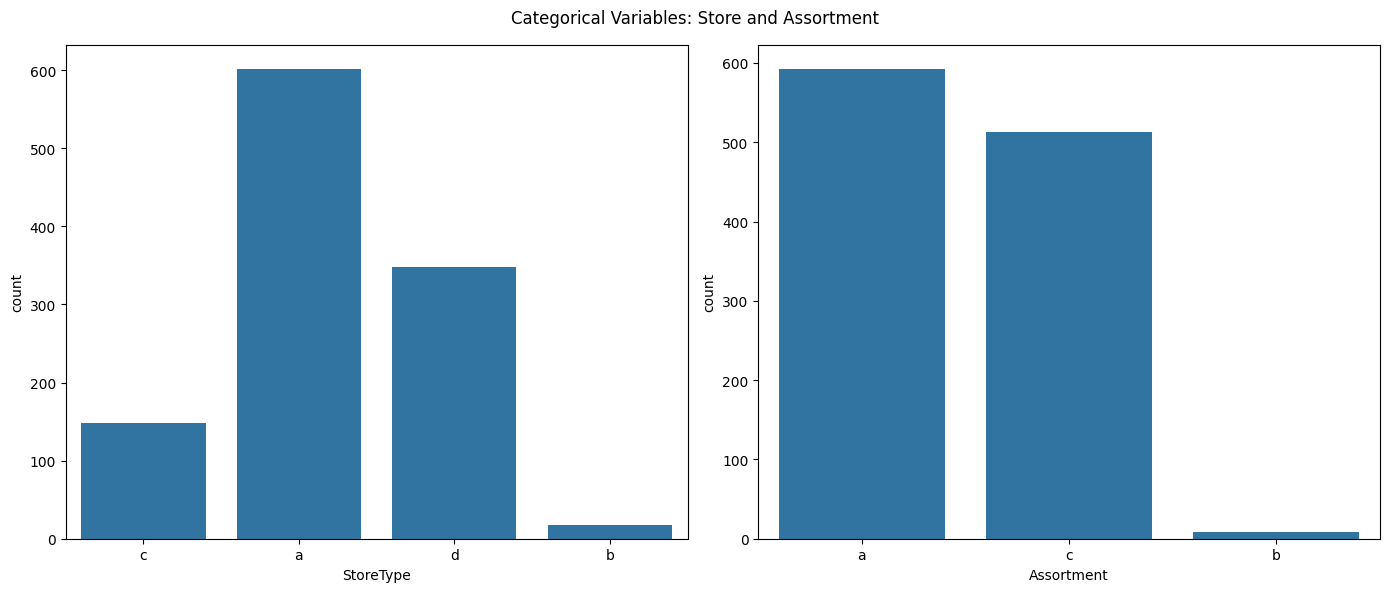

In [15]:
fig1, axes1 = plt.subplots(1, 2, figsize=(14, 6))
sns.countplot(data=single_df, x='StoreType', ax=axes1[0])
sns.countplot(data=single_df, x='Assortment', ax=axes1[1])
fig1.suptitle('Categorical Variables: Store and Assortment')
plt.tight_layout()
plt.show()

## Competition Variables: CompetitionOpenSinceYear and CompetitionDistance

***Competition Variables***  
The competition-related variables describe when and how close each store’s nearest competitor is located.  
For `CompetitionOpenSinceYear`, the summary shows that **761 stores** have valid entries, with an **average opening year of 2008.7** and a **median of 2010**.  
Most competitors opened between **2006 (25th percentile)** and **2013 (75th percentile)**, with the earliest recorded as **1900** and the most recent as **2015**.  
This suggests that the majority of competing stores emerged within the past two decades, indicating a steady rise in local market competition.  

For `CompetitionDistance`, all the same number of stores have distance data, where the rest were imputed with the median. The resulting **average distance of 5,397 meters** and a **median of 2,330 meters**.  
Half of the stores face competitors within roughly **0.7 to 6.9 km (25th–75th percentile)**, while some are located as far as **75.9 km** away.  
The wide range and large standard deviation (**7,654 m**) confirm that competitive proximity varies greatly across store locations.


In [53]:
comp_open = single_df[single_df['CompetitionOpenSinceYear'] > 0]

# Numerical summaries
comp_summary = comp_open['CompetitionOpenSinceYear'].describe()

dist_summary = single_df['CompetitionDistance'].describe()

# Combine summaries into a single table
comp_desc_stats = pd.concat([comp_summary, dist_summary], axis=1)
comp_desc_stats.loc['median'] = [comp_open['CompetitionOpenSinceYear'].median(), single_df['CompetitionDistance'].median()]
comp_desc_stats.columns = ['CompetitionOpenSinceYear', 'CompetitionDistance']
comp_desc_stats

,CompetitionOpenSinceYear,CompetitionDistance
count,761.000000,1115.000000
mean,2008.668857,5396.627803
std,6.195983,7654.508236
min,1900.000000,20.000000
25%,2006.000000,720.000000
50%,2010.000000,2330.000000
75%,2013.000000,6875.000000
max,2015.000000,75860.000000
median,2010.000000,2330.000000


**CompetitionOpenSinceYear**  
This variable records the year when the nearest competitor opened.  
The histogram shows a strong concentration from **2000 onward**, with a notable rise after **2010**, indicating that most competing stores are relatively recent.  
The skew toward later years suggests increasing retail competition over time, reflecting industry expansion ***or*** improved data availability in recent decades.   
While not clear in the visualization, the oldest store recorded as competition has been open since 1900 (assuming data is reliable).    
**Note that null values were replaced with zero previously. For the purposes of this visualization those rows have been excluded.**

**CompetitionDistance**  
`CompetitionDistance` measures the distance (in meters) to the nearest competitor.  
The distribution is **right-skewed**, with a majority of stores having competitors within **10,000 meters**, and a long tail extending beyond **70,000 meters**.  
This indicates that most Rossmann stores face nearby competition, while a small subset operate in relatively isolated regions.  
Together, these variables describe the competitive intensity surrounding each store, which is likely to influence sales performance.


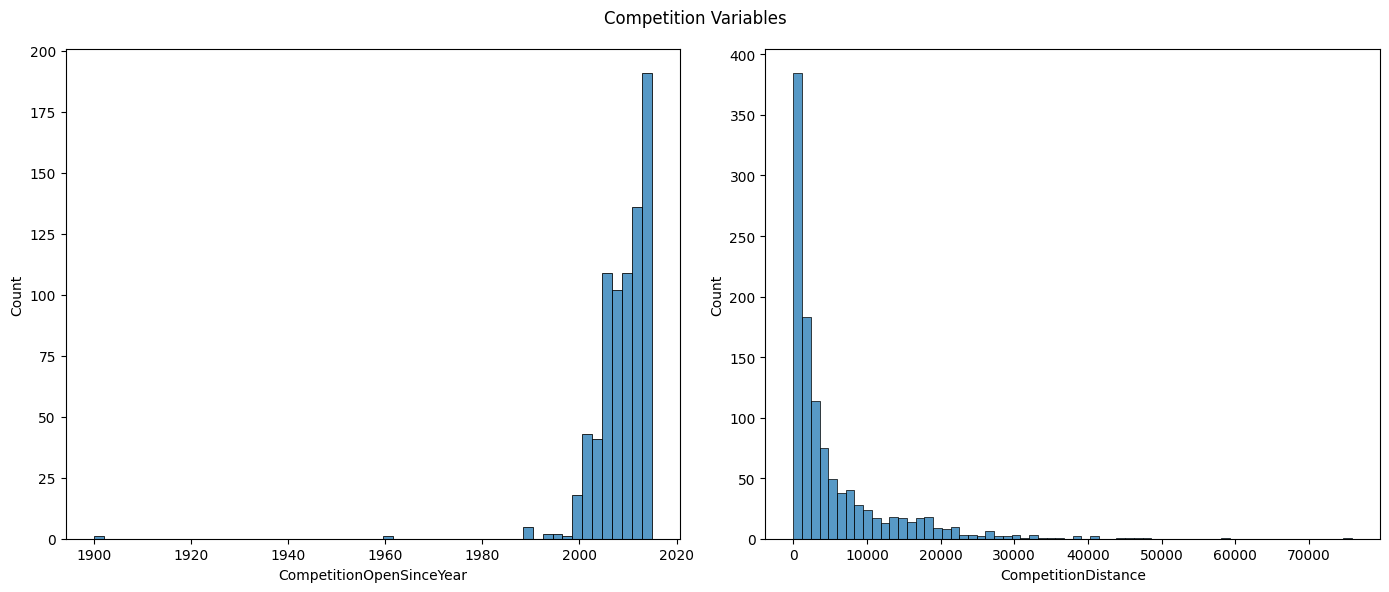

In [ ]:
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(data=comp_open,  x='CompetitionOpenSinceYear', ax=axes2[0])
sns.histplot(data=single_df, x='CompetitionDistance', ax=axes2[1])
fig2.suptitle('Competition Variables')
plt.tight_layout()
plt.show()

## Promotion Details: PromoInterval and Promo2SinceYear

***PromoInterval***   
The `PromoInterval` variable indicates the recurring months when continuous promotions (`Promo2`) restart.  
The tabulation shows that **544 stores (≈49%)** have `"0"`, meaning they **do not participate** in the continuous promotion cycle.  
Among the participating stores, the most common schedule is **"Jan,Apr,Jul,Oct" (335 stores, ≈30%)**, followed by **"Feb,May,Aug,Nov" (130 stores, ≈12%)**, and **"Mar,Jun,Sept,Dec" (106 stores, ≈9%)**. 

In [ ]:
df.groupby('Store')['PromoInterval'].unique().value_counts()

PromoInterval
[0]                   544
[Jan,Apr,Jul,Oct]     335
[Feb,May,Aug,Nov]     130
[Mar,Jun,Sept,Dec]    106
Name: count, dtype: int64

***Promo2SinceYear***  
The `Promo2SinceYear` variable records the year each store began participating in the continuous promotion program.  
The summary shows that **544 stores (≈49%)** have `[0.0]`, indicating **no participation** in `Promo2`.  
Among participating stores, most began between **2009 and 2014**, with the highest concentration in **2011 (128 stores, ≈12%)**, followed by **2013 (120 stores, ≈11%)** and **2014 (95 stores, ≈9%)**.  
Only a few stores joined as early as **2009** or as late as **2015**, though the latter may be a result of the dataset cutoff. 

In [61]:
df.groupby('Store')['Promo2SinceYear'].unique().value_counts()

Promo2SinceYear
[0.0]       544
[2011.0]    128
[2013.0]    120
[2014.0]     95
[2012.0]     81
[2009.0]     73
[2010.0]     64
[2015.0]     10
Name: count, dtype: int64

***PromoInterval***   
The plot shows that nearly half of the stores have **no active promotion cycle** (`"None"`). It should be noted that each store in this dataset only has one unique value for each PromoInterval, meaning for stores that do continuous promotions, they have only done so during **one of three quarterly schedules**: `"Jan,Apr,Jul,Oct"`, `"Feb,May,Aug,Nov"`, or `"Mar,Jun,Sept,Dec"`.  
These staggered intervals indicate a structured but selective promotion strategy where only a portion of stores engage in recurring campaigns, likely aligned with local marketing or operational planning.


**Promo2SinceYear**  
Participation increases sharply from **2010 to 2013**, peaking around **2011–2013**, then drops by **2015**, possibly due to either dataset cutoff or stabilization of program enrollment.  
This temporal spread indicates that Rossmann expanded the program gradually, and later entrants might differ in performance compared to early adopters.  
Combining both plots highlights that while many stores joined `Promo2` during the early 2010s, **a majority still do not maintain regular recurring promotions**.

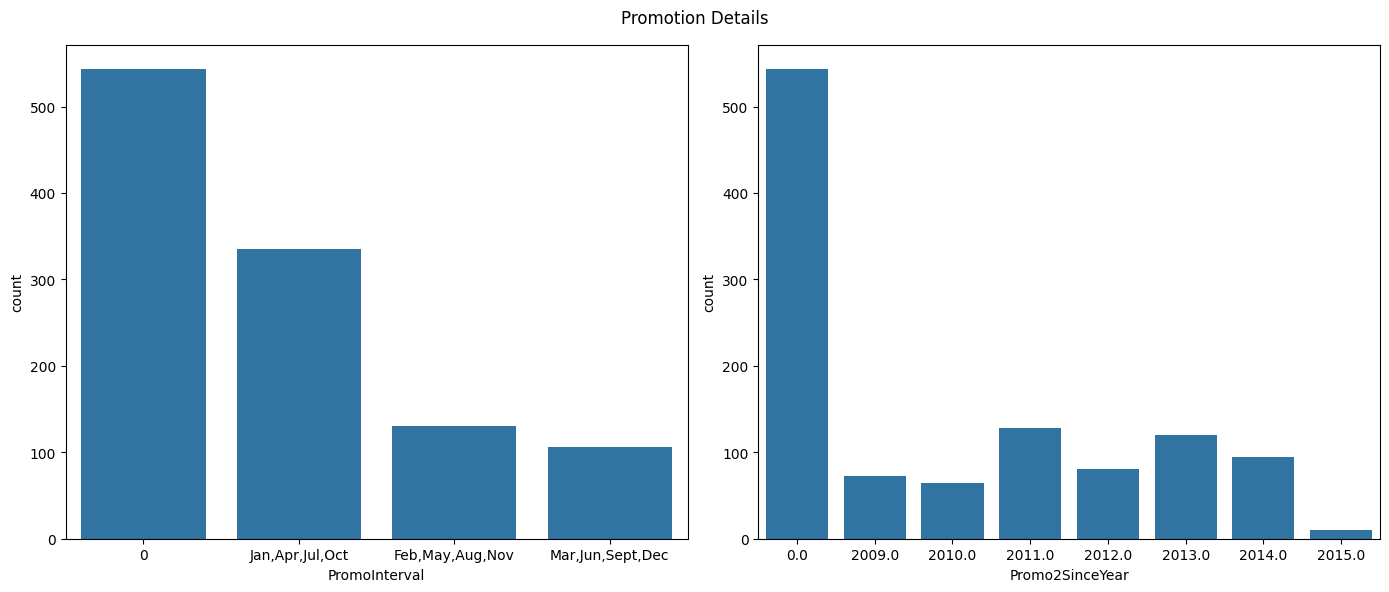

In [67]:
fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
y = (
    df.groupby('Store')['PromoInterval']
    .unique()
    .astype(str)
    .str.replace(r"[\[\]']", "", regex=True)
    .value_counts()
)
x = y.index
sns.barplot(x=x, y=y, ax=axes3[0])
sns.countplot(data=single_df, x='Promo2SinceYear', ax=axes3[1])
fig3.suptitle('Promotion Details')
plt.tight_layout()
plt.show()

### Binary Indicators  

**Open**  
The `Open` field indicates whether a store was operating (`1`) or closed (`0`) on a given day.  
The vast majority of observations show `Open = 1`, confirming that most records correspond to regular business days.  
Closed days are relatively rare and typically coincide with holidays or maintenance periods.  
This imbalance means models should treat closed days carefully—sales are always zero when `Open = 0`.

**Promo**  
The `Promo` variable denotes whether a store was running a promotion on a given day.  
Roughly two-thirds of the data shows `Promo = 0`, meaning most days have no active promotion.  
However, the significant number of `Promo = 1` entries implies that promotional events are frequent enough to potentially influence daily sales patterns.  
This feature is directly linked to demand spikes and should be a strong predictor in forecasting models.

**StateHoliday**  
`StateHoliday` identifies public holidays that can impact operations:  
`a = Public holiday`, `b = Easter`, `c = Christmas`, `0 = None`.  
The data shows an overwhelming majority of `0`, with very few instances of `a`, `b`, or `c`.  
Thus, while holidays strongly affect behavior, they occur infrequently in the dataset, making them sparse but high-impact variables.

**SchoolHoliday**  
This field indicates whether the date was affected by school closures.  
Most observations fall under `0`, meaning no school holiday, while a smaller but notable portion is marked `1`.  
These periods can influence customer flow, as family shopping behavior tends to shift when schools are closed.  
The pattern suggests that while school holidays are less common, they still occur regularly enough to affect weekly or seasonal sales trends.


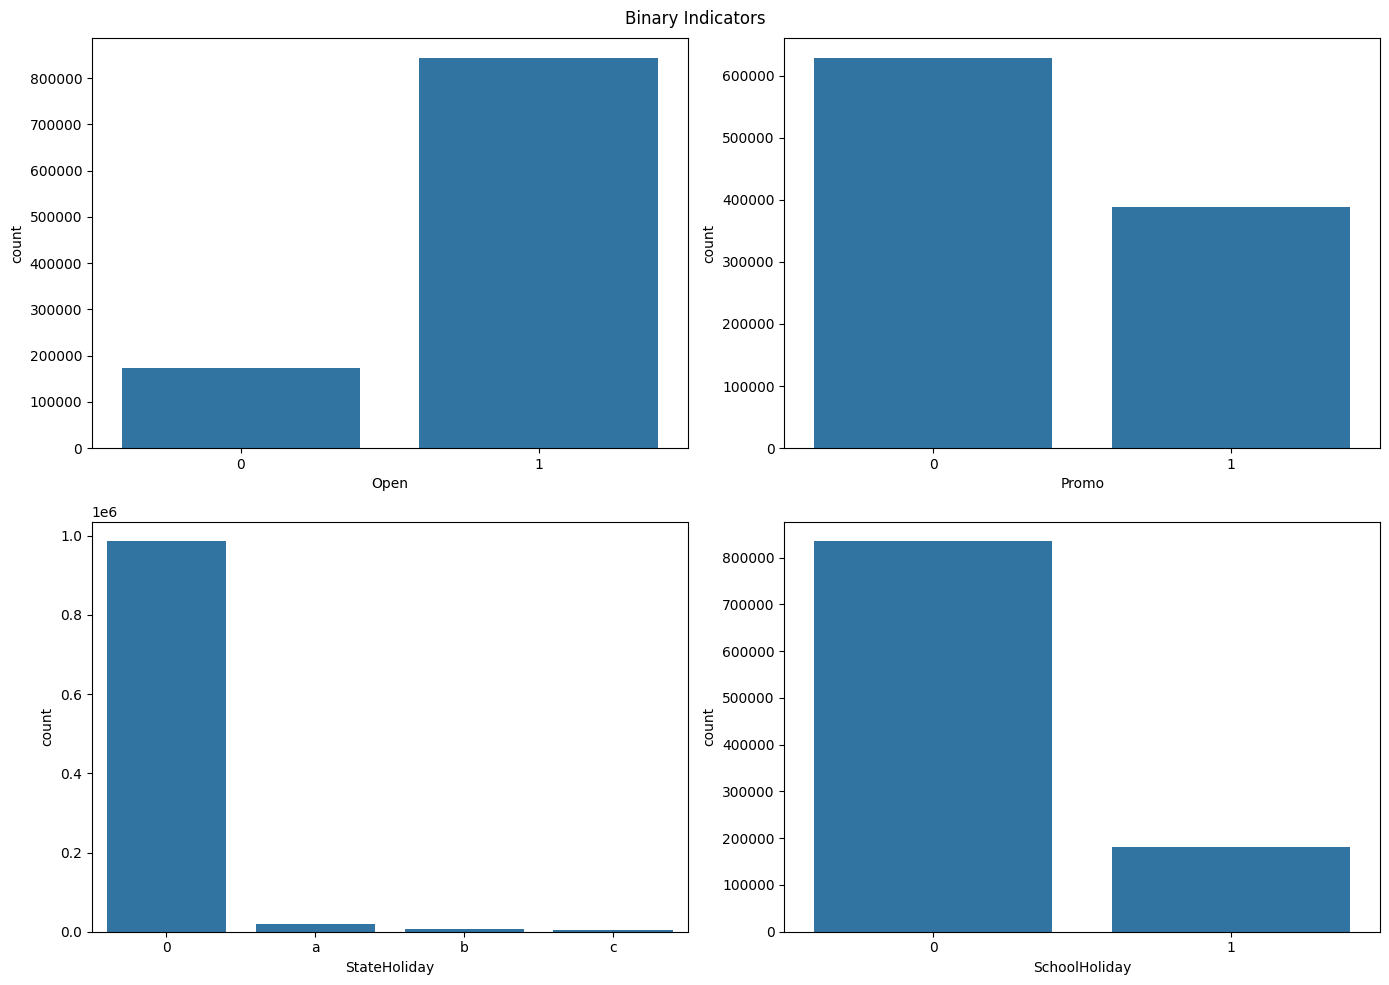

In [67]:
fig4, axes4 = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, x='Open', ax=axes4[0, 0])
sns.countplot(data=df, x='Promo', ax=axes4[0, 1])
sns.countplot(data=df, x='StateHoliday', ax=axes4[1, 0])
sns.countplot(data=df, x='SchoolHoliday', ax=axes4[1, 1])
fig4.suptitle('Binary Indicators')
plt.tight_layout()
plt.show()

### Performance Metrics (Open Stores Only)  

**Sales**  
The `Sales` variable represents daily turnover for each open store.  
When filtering out closed days (`Open = 0`), the distribution becomes **right-skewed**, with most stores recording daily sales between **5,000–10,000** units (presumably euros).  
A long tail extends toward higher values, showing that a few stores achieve exceptional turnover, possibly due to larger customer bases or regional advantages.  
The low occurrences of values near zero suggests that the decision filter out closed days was appropriate.  

**Customers**  
The `Customers` variable counts the number of shoppers on open days.  
Its distribution mirrors `Sales`, which is also **right-skewed** with most values below **1,000 customers per day**, and a long tail of high-traffic stores exceeding **2,000** customers.  
This alignment indicates a strong relationship between `Sales` and `Customers`, where higher footfall generally translates into higher revenue.  
Together, these two metrics provide the core of performance analysis with `Sales` as the output variable and `Customers` as a key factor.

In [48]:
open_df = df[df['Open'] == 1]

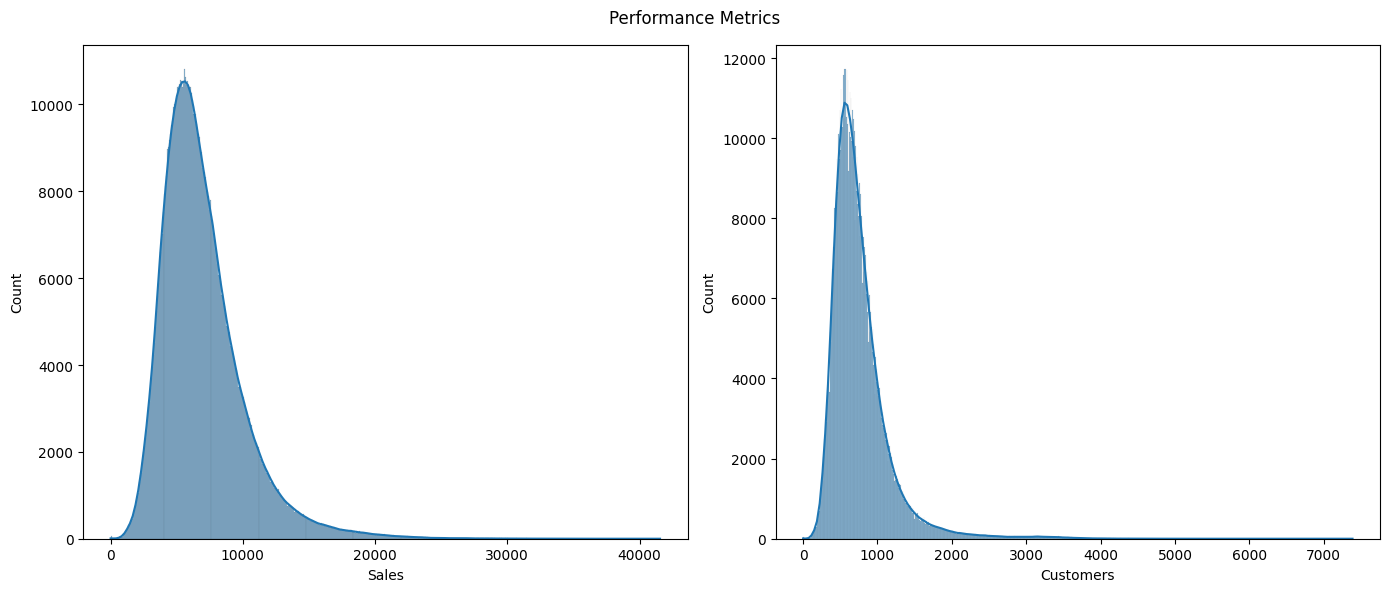

In [70]:
fig5, axes5 = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(data=open_df, kde=True, x='Sales', ax=axes5[0])
sns.histplot(data=open_df, kde=True, x='Customers', ax=axes5[1])
fig5.suptitle('Performance Metrics')
plt.tight_layout()
plt.show()

In [34]:
print("Number of records where a store's sales for the day were zero:", len(open_df[open_df['Sales'] == 0]))
print("Total number of records where the store was open:", len(open_df))

Number of records where a store's sales for the day were zero: 54
Total number of records where the store was open: 844392


# Bivariate Analysis

Text(0, 0.5, 'Count (log10 scale)')

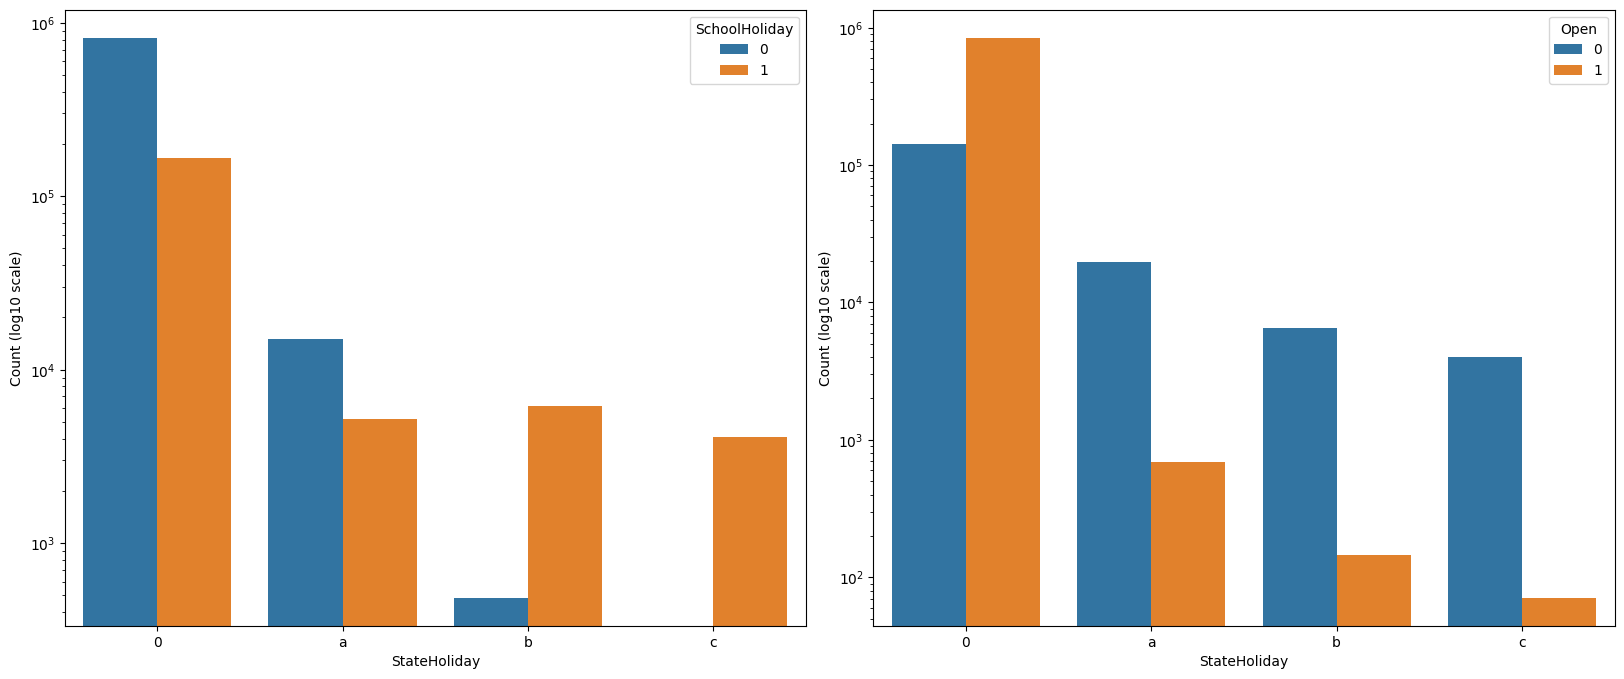

In [41]:
fig = plt.figure(figsize=(20, 8))
gs = fig.add_gridspec(1, 4)

ax0 = fig.add_subplot(gs[0, 0:2])
# ax1 = fig.add_subplot(gs[0, 2:])
ax1 = fig.add_subplot(gs[0, 2:])

axes = [ax0, ax1]
sns.countplot(data=df, x='StateHoliday', ax=axes[0], hue='SchoolHoliday')
sns.countplot(data=df, x='StateHoliday', ax=axes[1], hue='Open')
axes[0].set_yscale('log', base=10)
axes[0].set_ylabel("Count (log10 scale)")
axes[1].set_yscale('log', base=10)
axes[1].set_ylabel("Count (log10 scale)")

<Axes: xlabel='Customers', ylabel='Count'>

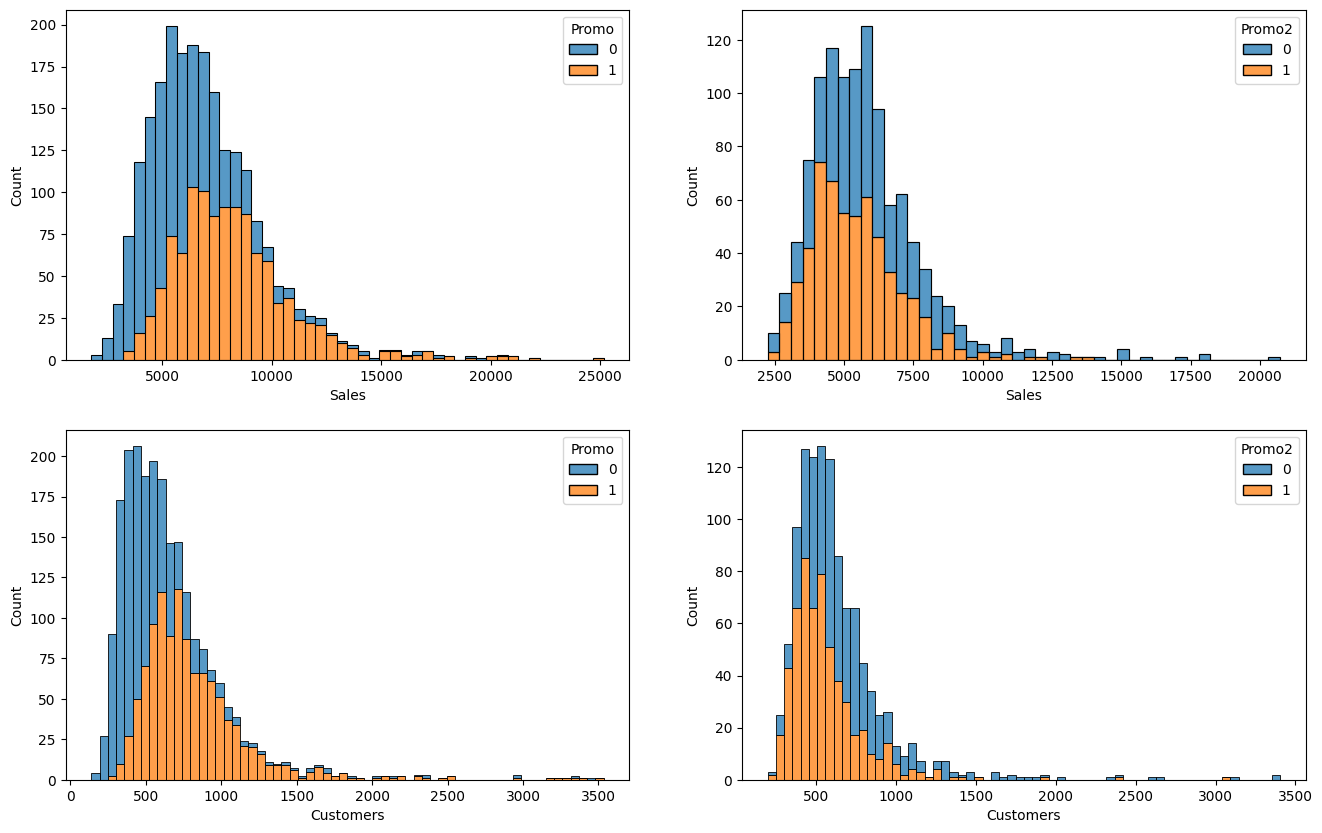

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
# Sales distributions
promo_sales = open_df.groupby(['Store', 'Promo'])['Sales'].mean().reset_index()
sns.histplot(data=promo_sales, x='Sales', hue='Promo', ax=axes[0,0], multiple='stack')
promo2_sales = df.groupby(['Store', 'Promo2'])['Sales'].mean().reset_index()
sns.histplot(data=promo2_sales, x='Sales', hue='Promo2', ax=axes[0,1], multiple='stack')
# Customer distributions
promo_customers = df.groupby(['Store', 'Promo'])['Customers'].mean().reset_index()
sns.histplot(data=promo_customers, x='Customers', hue='Promo', ax=axes[1,0], multiple='stack')
promo2_customers = df.groupby(['Store', 'Promo2'])['Customers'].mean().reset_index()
sns.histplot(data=promo2_customers, x='Customers', hue='Promo2', ax=axes[1,1], multiple='stack')

<Axes: ylabel='Customers'>

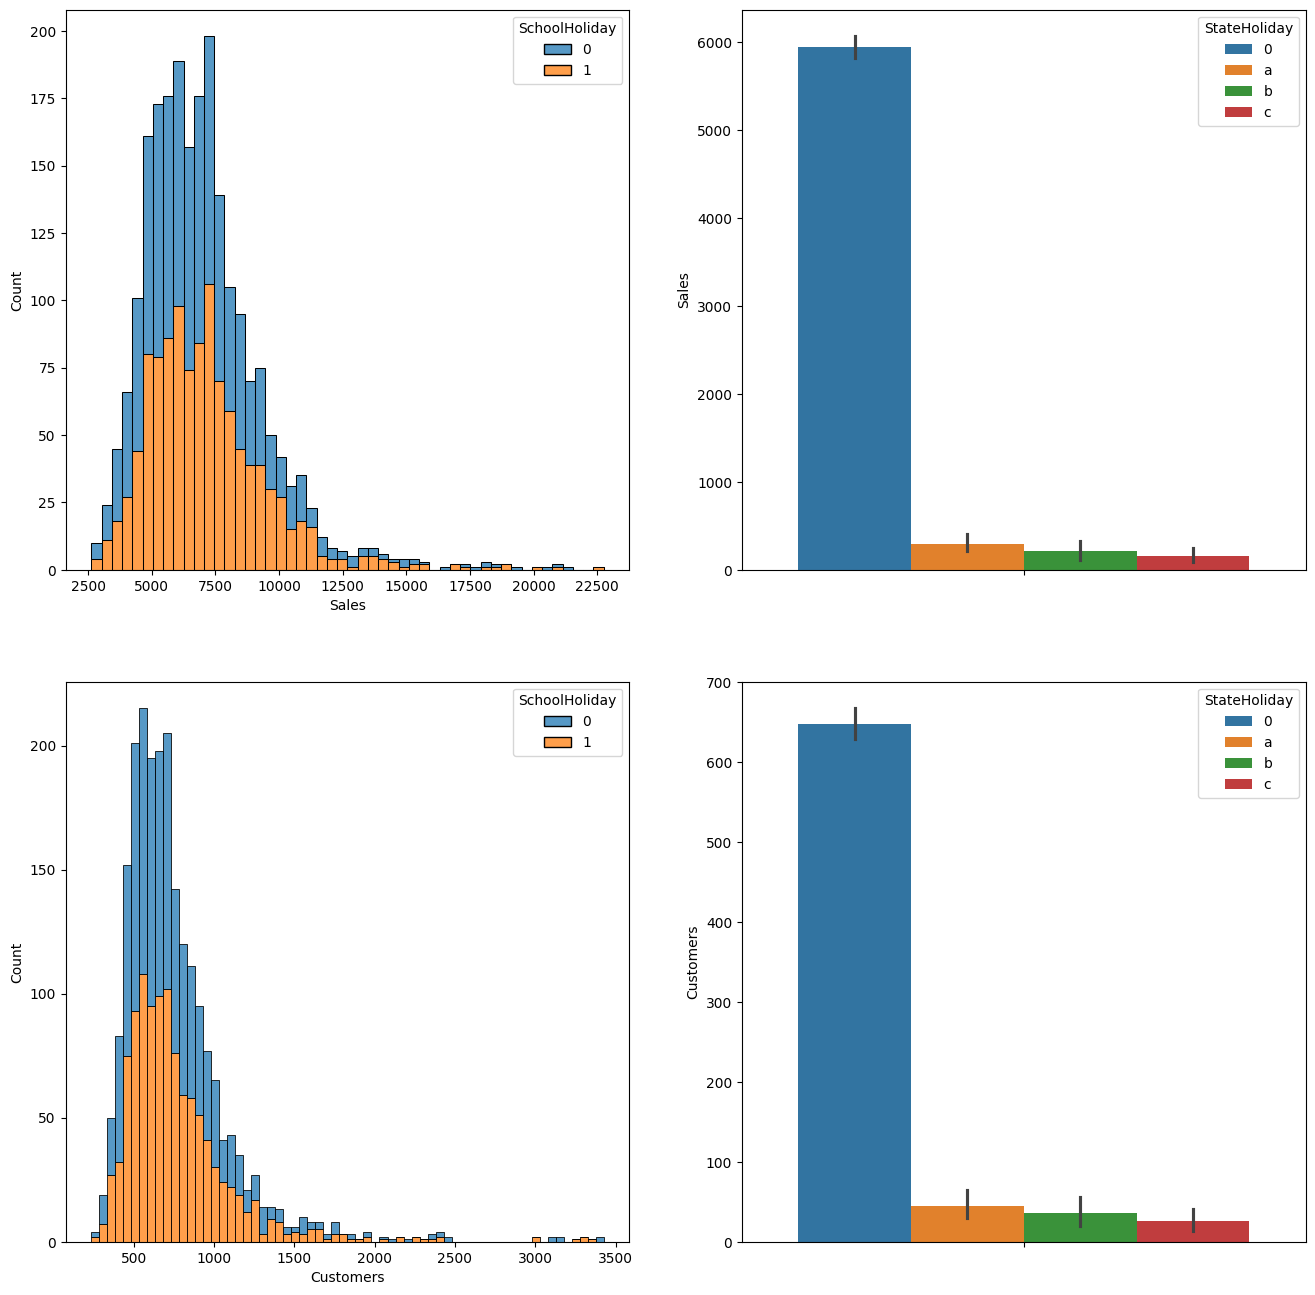

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
# Sales distributions, granted store is open
school_sales = sold_df.groupby(['Store', 'SchoolHoliday'])['Sales'].mean().reset_index()
sns.histplot(data=school_sales, x='Sales', hue='SchoolHoliday', ax=axes[0,0], multiple='stack')
state_sales = df.groupby(['Store', 'StateHoliday'])['Sales'].mean().reset_index()
sns.barplot(data=state_sales, y='Sales', hue='StateHoliday', ax=axes[0,1])

# Customer distributions, granted store is open
school_customers = sold_df.groupby(['Store', 'SchoolHoliday'])['Customers'].mean().reset_index()
sns.histplot(data=school_customers, x='Customers', hue='SchoolHoliday', ax=axes[1,0], multiple='stack')
state_customers = df.groupby(['Store', 'StateHoliday'])['Customers'].mean().reset_index()
sns.barplot(data=state_customers, y='Customers', hue='StateHoliday', ax=axes[1,1])

<Axes: ylabel='Customers'>

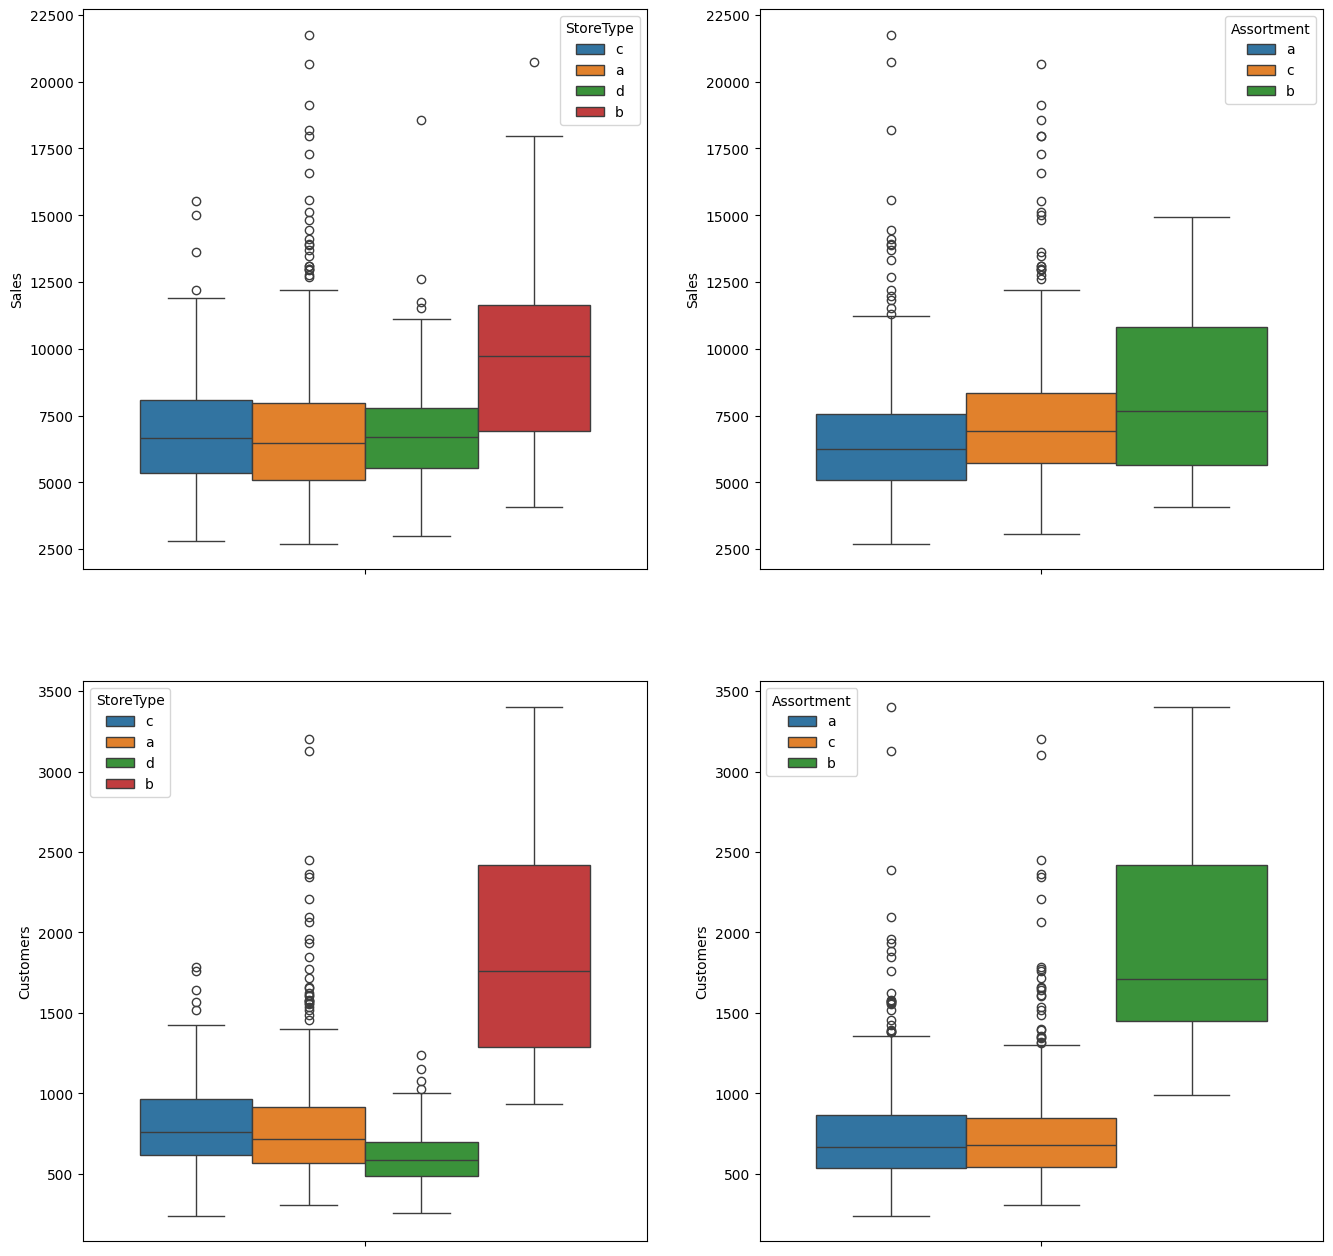

In [27]:
sold_df = df[df['Open'] != 0]
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
# Sales distributions
store_type_sales = sold_df.groupby(['Store', 'StoreType'])['Sales'].mean().reset_index()
sns.boxplot(data=store_type_sales, y='Sales', hue='StoreType', ax=axes[0,0])
assortment_sales = sold_df.groupby(['Store', 'Assortment'])['Sales'].mean().reset_index()
sns.boxplot(data=assortment_sales, y='Sales', hue='Assortment', ax=axes[0,1])

store_type_customers = sold_df.groupby(['Store', 'StoreType'])['Customers'].mean().reset_index()
sns.boxplot(data=store_type_customers, y='Customers', hue='StoreType', ax=axes[1,0])
assortment_customers = sold_df.groupby(['Store', 'Assortment'])['Customers'].mean().reset_index()
sns.boxplot(data=assortment_customers, y='Customers', hue='Assortment', ax=axes[1,1])

In [34]:
# sold_df = df[df['Open'] != 0]
# indexed_df = sold_df.copy()
indexed_df = df.copy()
indexed_df['Date'] = pd.to_datetime(df['Date'])  # ensure datetime
indexed_df = indexed_df.set_index('Date')                # set as index
indexed_df = indexed_df.sort_index()                     # ensure chronological order
weekly_sales = indexed_df['Sales'].resample('M').sum()
weekly_customers = indexed_df['Customers'].resample('M').sum()

/tmp/ipykernel_4811/387364767.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weekly_sales = indexed_df['Sales'].resample('M').sum()
/tmp/ipykernel_4811/387364767.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weekly_customers = indexed_df['Customers'].resample('M').sum()


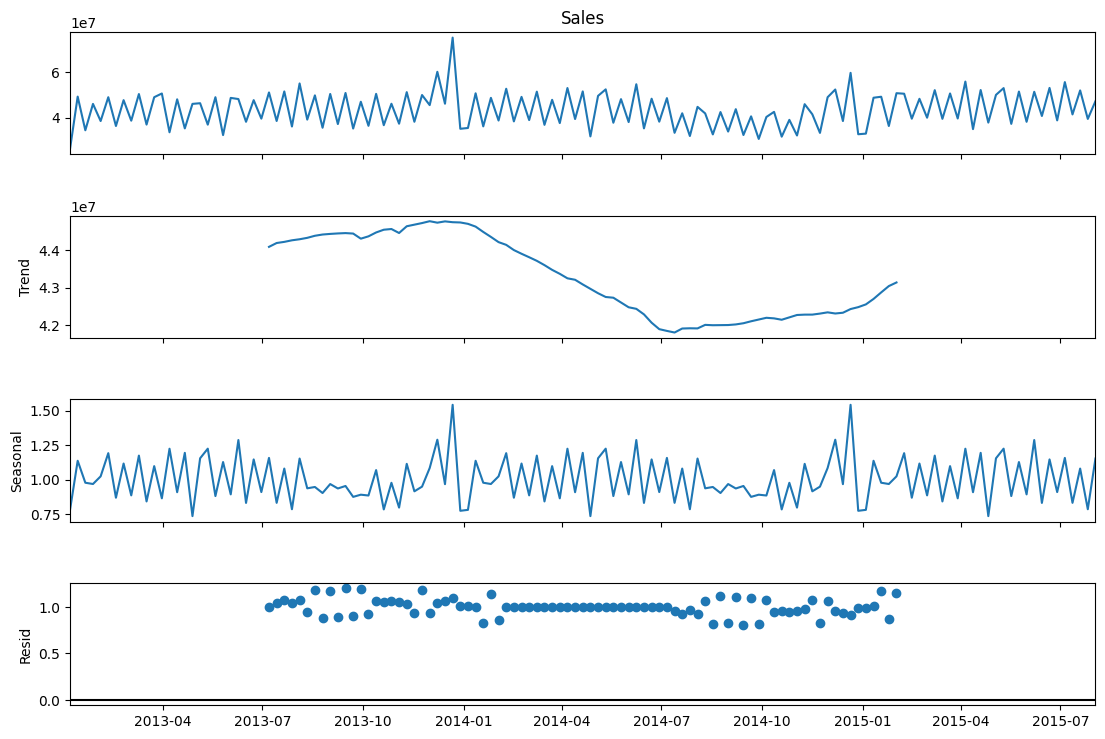

In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(weekly_sales, model='multiplicative', period=52)

fig = result.plot()
fig.set_size_inches(12, 8)  # enlarge figure
plt.show()

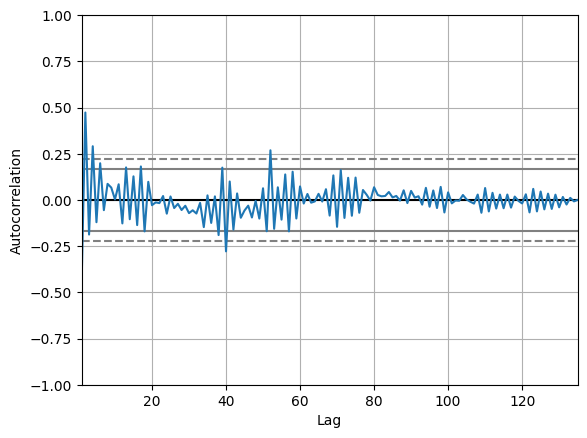

In [29]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(weekly_sales)
print(result)

In [30]:
df_2013 = indexed_df[(indexed_df.index > pd.Timestamp(date(2013, 1, 1))) & (indexed_df.index < pd.Timestamp(date(2013, 12, 31)))]
df_2014 = indexed_df[(indexed_df.index > pd.Timestamp(date(2014, 1, 1))) & (indexed_df.index < pd.Timestamp(date(2014, 12, 31)))]
df_2015 = indexed_df[(indexed_df.index > pd.Timestamp(date(2015, 1, 1))) & (indexed_df.index < pd.Timestamp(date(2015, 12, 31)))]

In [31]:
comp_df = indexed_df[(indexed_df['CompOpenDate'] > date(2014, 1, 1)) & (indexed_df['CompOpenDate'] < date(2014, 7, 31))]

In [32]:
print(comp_df['Store'].unique())

[ 423  369  361  416  386  336  318  488   30   14   57   52   45  213
  275  270  268  266  264  169  166  189  947  905  901 1111  983 1019
  653  635  629  683  677  585  601  604  800  715  740]


In [33]:
from dateutil.relativedelta import relativedelta

prev = comp_df[(comp_df['Store'] == 423) & (comp_df.index == comp_df['CompOpenDate'] - relativedelta(years=1))]['Sales']
open_d = comp_df[(comp_df['Store'] == 423) & (comp_df.index == comp_df['CompOpenDate'])]['Sales']
after = comp_df[(comp_df['Store'] == 423) & (comp_df.index == comp_df['CompOpenDate'] + relativedelta(years=1))]['Sales']

In [120]:
deltas = []
comp_distances = []
mean_before = []
mean_after = []
mean_all_time = []
for store in comp_df['Store'].unique():
    prev_year = comp_df[
    (comp_df['Store'] == store)
    & (comp_df.index >= comp_df['CompOpenDate'] - relativedelta(years=1))
    & (comp_df.index <= comp_df['CompOpenDate'])
    ]['Sales'].mean()

    year_after = comp_df[
    (comp_df['Store'] == store)
    & (comp_df.index <= comp_df['CompOpenDate'] + relativedelta(years=1))
    & (comp_df.index >= comp_df['CompOpenDate'])
    ]['Sales'].mean()

    mean_at = comp_df[
    (comp_df['Store'] == store)
    ]['Sales'].mean()

    comp_distances.append(single_df[single_df['Store'] == store]['CompetitionDistance'].values[0])
    mean_before.append(prev_year)
    mean_after.append(year_after)
    mean_all_time.append(mean_at)
    deltas.append(year_after - prev_year)

<Axes: ylabel='Count'>

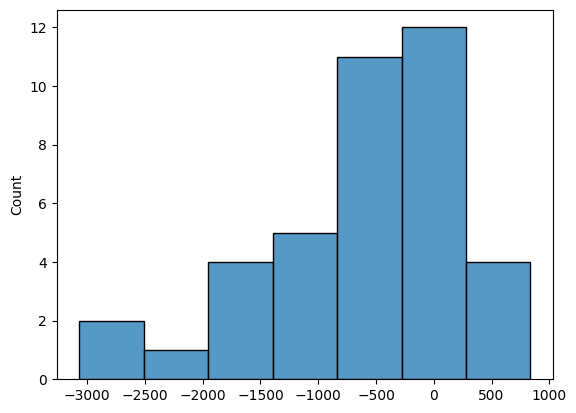

In [121]:
sns.histplot(deltas)

<Axes: ylabel='Count'>

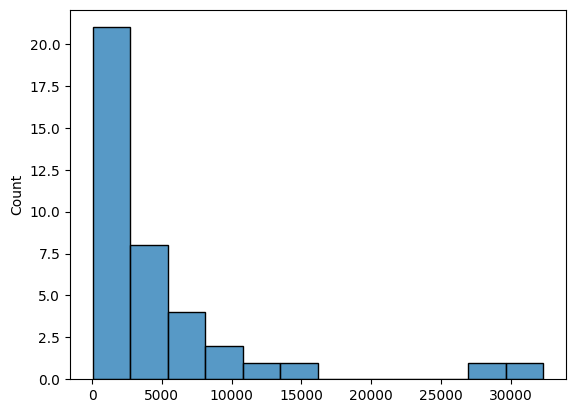

In [122]:
sns.histplot(comp_distances)

In [124]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import kendalltau
rho, p = pearsonr(deltas, comp_distances)
print(p)
if p < 0.05:
    print("type shit")
else:
    print("cooked fr")

0.020439400495000478
type shit


<Axes: >

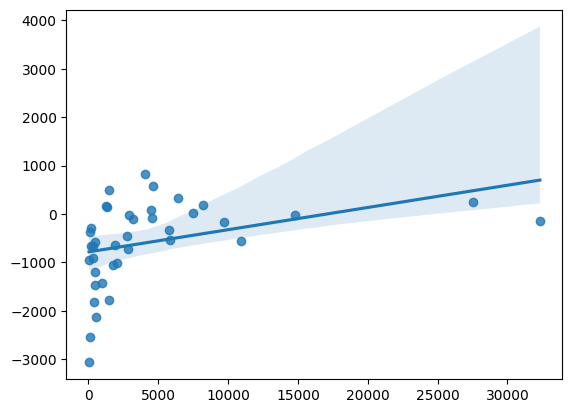

In [125]:
sns.regplot(x=comp_distances, y=deltas)

In [126]:
from scipy.stats import ttest_rel
t_stat, p = ttest_rel(mean_before, mean_after)
if p < 0.05:
    print("type shit")
else:
    print("cooked fr")

type shit


In [114]:
mean_sales = []
comp_distances_all = []
for store in single_df['Store'].unique():
    comp = single_df[single_df['Store'] == store]['CompetitionDistance'].values[0]
    if np.isnan(comp) == False and float(comp) > 0:
        mean_all_time = indexed_df[(indexed_df['Store'] == store)]['Sales'].mean()
        comp_distances_all.append(comp)
        mean_sales.append(mean_all_time)

<Axes: ylabel='Count'>

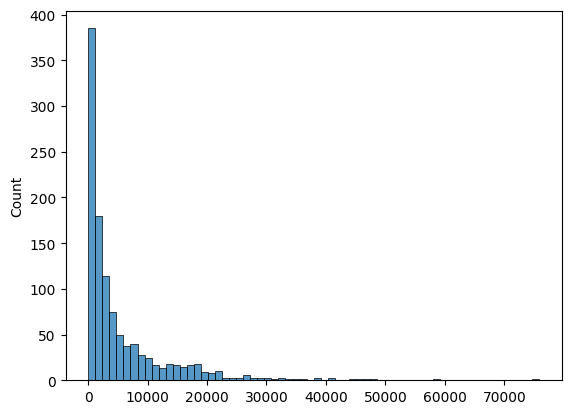

In [115]:
sns.histplot(comp_distances_all)

<Axes: ylabel='Count'>

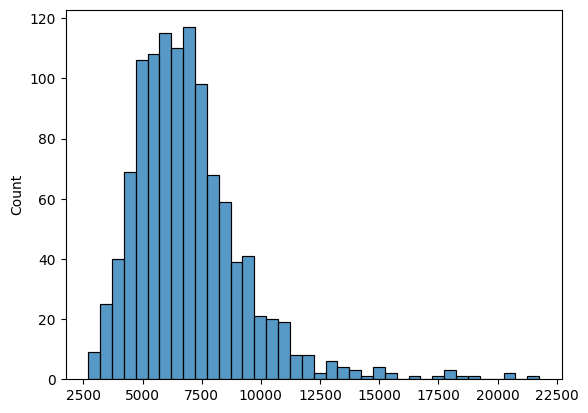

In [116]:
sns.histplot(mean_sales)

In [118]:
from scipy.stats import shapiro
stat, p = shapiro(comp_distances_all)
if p > 0.05:
    print('Normal')
else:
    print('Not Normal')

Not Normal


In [119]:
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import kendalltau
r, p = spearmanr(comp_distances_all, mean_sales)
print(p)
if p < 0.05:
    print("type shit")
else:
    print("cooked fr")
print(r)

0.3506520286111865
cooked fr
-0.028014580616245583


<Axes: >

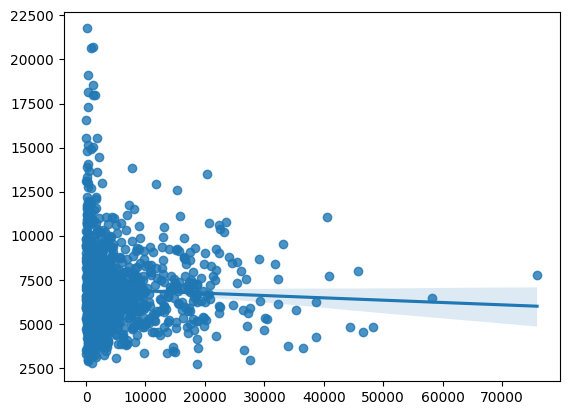

In [83]:
sns.regplot(x=comp_distances_all, y=mean_sales)